In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# Import MCMC first so that JAX gets set up with 8 cores.
import sys
sys.path.append('../../python/example/berry')
import mcmc

import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
from scipy.special import logit

import util
import fast_inla
import quadrature

In [7]:
n_arms = 2
fi = fast_inla.FastINLA(n_arms=n_arms, sigma2_n=90)

# Compute for a grid of y values ranging from 0 to 9 with n = 35
ys = np.arange(0, 10)
Y1, Y2 = np.meshgrid(ys, ys)
y_i = np.stack((Y1.ravel(), Y2.ravel()), axis=-1)
n_i = np.full_like(y_i, 35)

In [21]:
import mcmc

results_mcmc = mcmc.mcmc_berry(
    np.stack((y_i, n_i), axis=-1),
    fi.logit_p1,
    np.full(data.shape[0], fi.thresh_theta),
    n_arms=n_arms,
    dtype=np.float64,
    n_samples=20000
)

In [ ]:
def compare_arm_marginals(y, n, arm_idx, plot_idx, ti_N=51, results_mcmc=None):
    print('arm_idx=', arm_idx, ' y=', y[plot_idx])
    ti_rule = util.simpson_rule(ti_N, -6.0, 2.0)

    sigma2_post, _, theta_mu, theta_sigma, _ = fi.numpy_inference(y, n)

    integrate_dims = list(range(n_arms))
    integrate_dims.remove(arm_idx)
    quad_p_ti_g_y = quadrature.integrate(
        fi,
        y[plot_idx : (plot_idx + 1)],
        n[plot_idx : (plot_idx + 1)],
        integrate_sigma2=True,
        fixed_arm_dim=arm_idx,
        fixed_arm_values=ti_rule.pts,
        n_theta=15,
    )
    quad_p_ti_g_y /= np.sum(quad_p_ti_g_y * ti_rule.wts, axis=1)[:, None]

    gaussian_pdf = scipy.stats.norm.pdf(
        ti_rule.pts[:, None],
        theta_mu[plot_idx, :, arm_idx],
        theta_sigma[plot_idx, :, arm_idx],
    )
    gaussian_p_ti_g_y = np.sum(
        gaussian_pdf * sigma2_post[plot_idx] * fi.sigma2_rule.wts[None, :], axis=1
    )

    # construct bin edges such that the bin midpoints correspond to ti_rule.pts
    mcmc_arm = results_mcmc["x"][plot_idx]["theta"][0, :, arm_idx].to_py()
    mcmc_p_ti_g_y = mcmc.calc_pdf(mcmc_arm, ti_rule.pts)

    plt.plot(ti_rule.pts, gaussian_p_ti_g_y, "k-", markersize=3, label="INLA")
    plt.plot(ti_rule.pts, quad_p_ti_g_y[0], "k--", markersize=3, label="Quadrature")
    plt.plot(ti_rule.pts, mcmc_p_ti_g_y, "k.", label="MCMC")

    plt.title()
    plt.xlabel(r"$\theta_" + str(arm_idx) + "$")
    plt.ylabel(r"p($\theta_" + str(arm_idx) + "$ | y)")
    plt.legend()
    plt.show()

arm_idx= 0  y= [8 4]


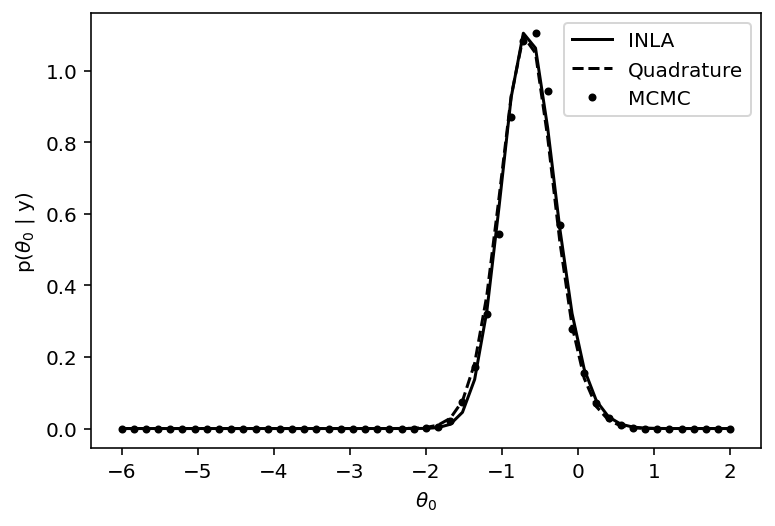

arm_idx= 1  y= [4 8]


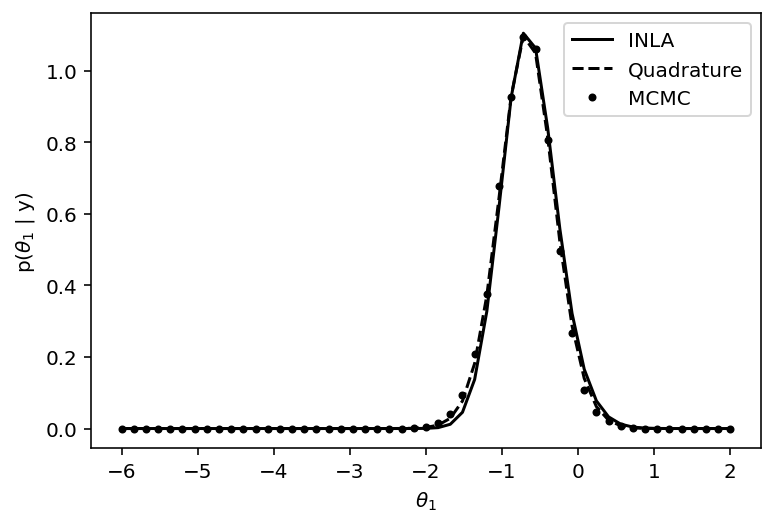

arm_idx= 1  y= [8 0]


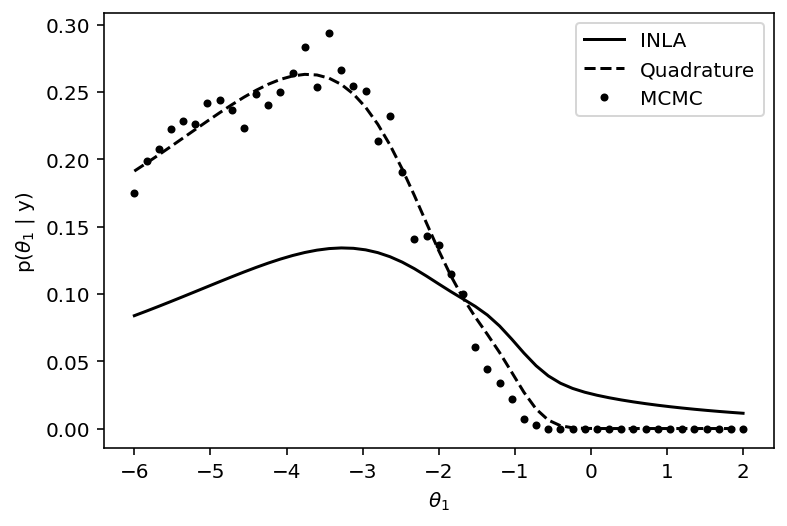

arm_idx= 1  y= [1 0]


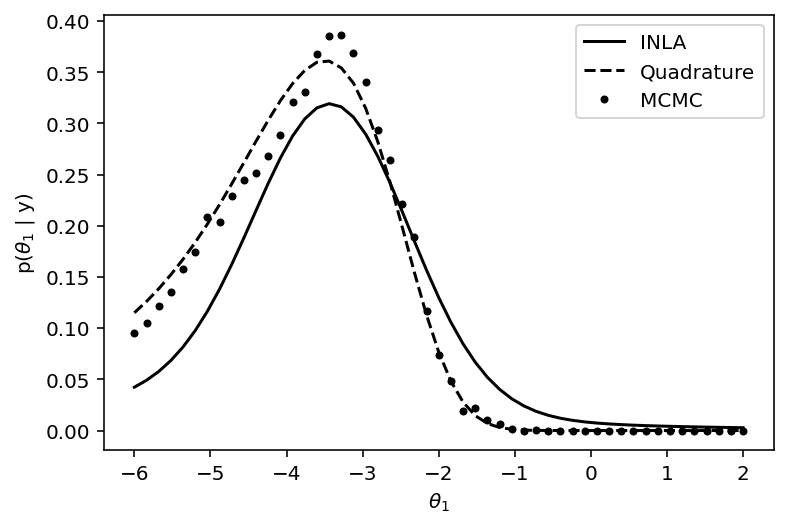

arm_idx= 0  y= [0 0]


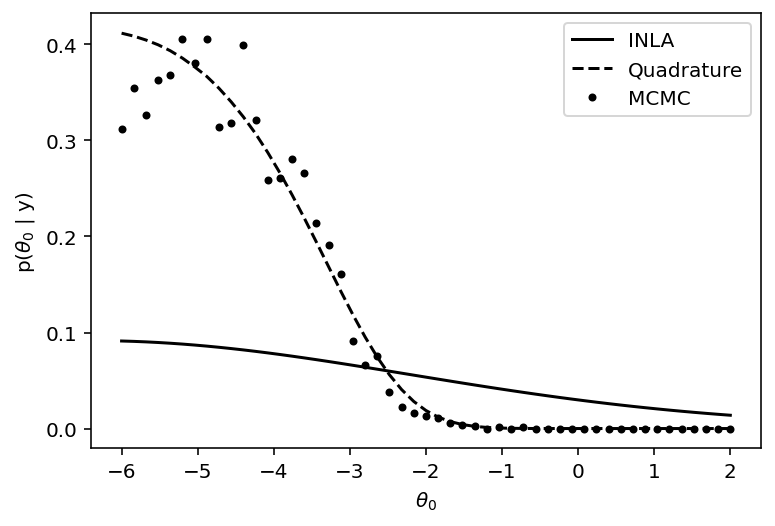

In [ ]:
for arm_idx, plot_idx in [(0, 48), (1, 84), (1, 8), (1, 1), (0,0)]:
    compare_arm_marginals(y_i, n_i, arm_idx, plot_idx, results_mcmc=results_mcmc)

In [19]:
def compare_hyperparam_posterior(plot_idx):
    quad_p_s2_g_y = quadrature.integrate(
        fi,
        y_i[plot_idx:(plot_idx + 1)],
        n_i[plot_idx:(plot_idx + 1)],
        integrate_sigma2=False,
        n_theta=15,
    )
    quad_p_s2_g_y /= np.sum(quad_p_s2_g_y * fi.sigma2_rule.wts, axis=1)

    mcmc_sigma2 = results_mcmc["x"][plot_idx]["sigma2"][0, :].to_py()
    mcmc_p_s2_g_y = mcmc.calc_pdf(mcmc_sigma2, fi.sigma2_rule.pts, fi.sigma2_rule.wts)

    plt.plot(np.log10(fi.sigma2_rule.pts), sigma2_post[plot_idx], "k-", markersize=3, label="INLA-Gaussian")
    plt.plot(np.log10(fi.sigma2_rule.pts), quad_p_s2_g_y[0], "k--", markersize=3, label="Quad")
    plt.plot(np.log10(fi.sigma2_rule.pts), mcmc_p_s2_g_y, "ko", markersize=3, label="MCMC")
    plt.xlabel('$\log_{10} (\sigma^2)$')
    plt.ylabel('$p(\sigma^2 | y)$')
    plt.legend()
    plt.show()

    plt.plot(np.log10(fi.sigma2_rule.pts), sigma2_post[plot_idx] * fi.sigma2_rule.wts, "k-", markersize=3, label="INLA-Gaussian")
    plt.title(f'compare y=[{y_i[plot_idx,0]},{y_i[plot_idx,1]}], n=[35,35]')
    plt.plot(np.log10(fi.sigma2_rule.pts), quad_p_s2_g_y[0] * fi.sigma2_rule.wts, "k--", markersize=3, label="Quad")
    plt.plot(np.log10(fi.sigma2_rule.pts), mcmc_p_s2_g_y * fi.sigma2_rule.wts, "ko", markersize=3, label="MCMC")
    plt.legend()
    plt.xlabel('$\log_{10} (\sigma^2)$')
    plt.ylabel('$p(\sigma^2 | y) * w$')
    plt.show()

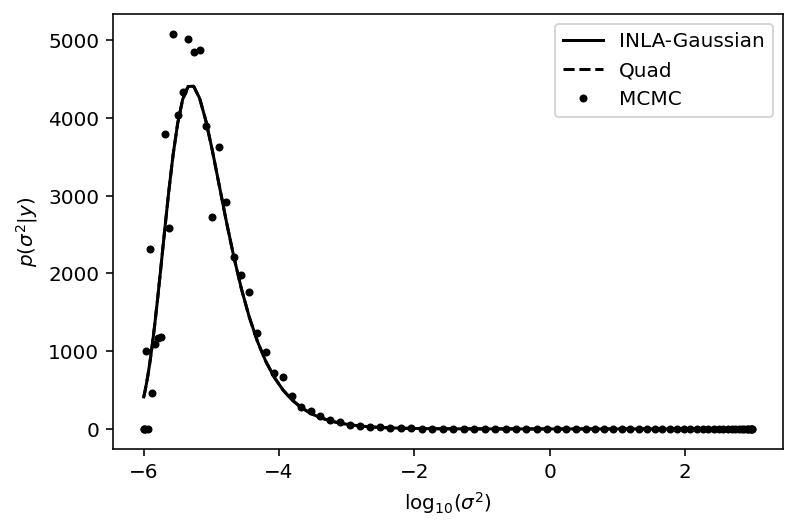

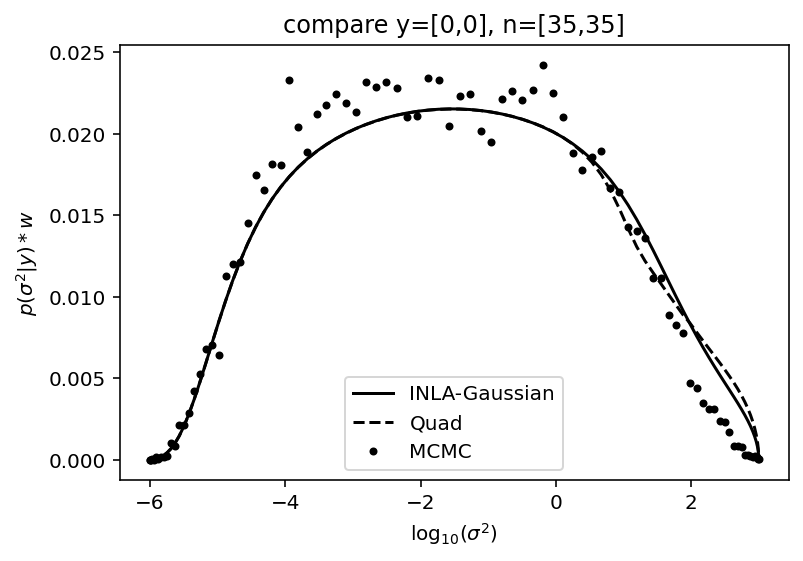

In [20]:
for arm_idx, plot_idx in [(1, 0)]:
    compare_hyperparam_posterior(plot_idx)